In [1]:
import math
import csv
import random
import numpy as np
import gymnasium as gym

from time import sleep
from collections import deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

In [2]:
# Check PyTorch GPU availability and basic operation
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    x = torch.randn(2, 2, device="cuda")
    y = torch.randn(2, 2, device="cuda")
    print("Sample CUDA tensor sum:\n", (x + y))
else:
    print("GPU not detected; running on CPU.")

CUDA available: False
GPU not detected; running on CPU.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # state shape: (seq_len, input_size)
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class LSTM_DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_DQN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Takes sequence of viewports
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layer: Maps LSTM output to Q-values (one per tile index)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len, input_size)
        
        # LSTM output shape: (batch, seq_len, hidden_size)
        lstm_out, hidden = self.lstm(x, hidden)
        
        # We only care about the output of the last time step for prediction
        last_time_step = lstm_out[:, -1, :]
        
        # Q-values
        q_values = self.fc(last_time_step)
        return q_values, hidden

class DQNAgent:
    def __init__(
        self, 
        n_tiles, 
        seq_len, 
        learning_rate=1e-3, 
        gamma=0.99,
        batch_size=64,
        capacity=10000,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995
    ):
        self.n_tiles = n_tiles
        self.seq_len = seq_len
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.policy_net = LSTM_DQN(n_tiles, 32, n_tiles).to(device)
        self.target_net = LSTM_DQN(n_tiles, 32, n_tiles).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(
            self.policy_net.parameters(), 
            lr=learning_rate
        )

        self.criterion = nn.MSELoss()
        self.memory = ReplayMemory(capacity=capacity)
        self.batch_size = batch_size

    def select_action(self, state_seq):
        """
        state_seq: numpy array of shape (seq_len, n_tiles)
        Returns: integer index of the predicted center tile
        """
        if random.random() < self.epsilon:
            return random.randrange(self.n_tiles), None
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state_seq).unsqueeze(0).to(device)
                q_values, _ = self.policy_net(state_tensor)
                return q_values.argmax().item(), q_values.cpu().numpy()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to tensors
        states = torch.FloatTensor(np.array(states)).to(device)      # (B, Seq, Input)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)  # (B, 1)
        rewards = torch.FloatTensor(rewards).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).to(device)

        # Compute Q(s, a)
        q_values, _ = self.policy_net(states)
        state_action_values = q_values.gather(1, actions).squeeze(1)

        # Compute V(s')
        with torch.no_grad():
            next_q_values, _ = self.target_net(next_states)
            next_state_values = next_q_values.max(1)[0]
            expected_state_action_values = rewards + (self.gamma * next_state_values * (1 - dones))

        # Loss and Optimize
        loss = self.criterion(state_action_values, expected_state_action_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [4]:
def index_to_fov_mask(center_idx, n):
    """
    Converts a predicted center tile index into a binary mask of neighbors.
    Simulates a 3x3 (or specific FOV) grid around the center.
    """
    mask = np.zeros(n*n, dtype=int)
    
    # Grid coordinates
    cy, cx = divmod(center_idx, n)
    
    # Define a simple FOV range (e.g., center + immediate neighbors)
    # Adjust range to match the desired viewport size (roughly 90 deg)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < n and 0 <= nx < n:
                mask[ny * n + nx] = 1
                
    return mask

In [ ]:
if __name__ == "__main__":
    n_episodes = 200
    n_users = 100
    step_size = 5.0
    arrival_rate = 5.0  # users per second
    max_users_capacity = n_users
    alpha = 1.0
    n_videos = 100
    n_gops = 60
    n_layers = 2
    n = 4
    n_tiles = n * n
    max_capacity = 100e6  # 100 MB

    # Hyperparameters for RL
    epsilon_start = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    learning_rate = 1e-3
    batch_size = 64
    capacity = 10000
    seq_len = 5  # LSTM sequence length (history window)

    # CPT parameters
    theta = 0.5
    lam = 3.7183

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_users=n_users,
        n_videos=n_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n=n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=arrival_rate
    )

    cache_env = CacheEngineEnv(
        n_users=n_users,
        n_videos=n_videos,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n_gops=n_gops,
        cache_capacity=max_capacity,
    )

    # Create latency model (replace numbers with your real config)
    P = 1; max_U = n_users
    lat_model = LatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9, # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),    # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model,
        theta=theta,
        lam=lam
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {n_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )

    agent = DQNAgent(
        n_tiles=n_tiles, 
        seq_len=seq_len,
        learning_rate=learning_rate,
        gamma=gamma,
        batch_size=batch_size,
        capacity=capacity,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    results = []
    scores = []
    active_users_log = []  # Track active users per step

    for ep in range(n_episodes):

        obs, info = env.reset()
        requested_videos = info['requested_videos']
        viewport_tiles = info['viewport_tiles']
        users_arrivals = info['users_arrivals'] 
        
        # User State History: Dictionary to track last 'seq_len' viewports per user
        # Initialize with zeros
        next_user_id = 0
        user_histories = {
            u: deque(
                [np.zeros(n*n) for _ in range(seq_len)], maxlen=seq_len
            ) for u in range(max_users_capacity)
        }

        cache_hits = 0
        cache_misses = 0
        total_reward = 0.0

        for step in count():

            # --- AGENT ACTIONS ---
            actions = []
            user_action_indices = {} # Store discrete action (center tile) for training
            
            active_users = []

            for u in range(len(users_arrivals)):
                if step > users_arrivals[u] and step < users_arrivals[u] + n_gops:
                    active_users.append(u)

            # Log active users
            active_users_log.append({
                'episode': ep,
                'step': step,
                'num_active_users': len(active_users),
                'active_user_ids': ','.join(map(str, active_users))
            })

            for u in active_users:
                # Construct state from history
                cur_state_seq = np.array(user_histories[u]) # Shape (seq_len, 16)
                
                # Agent chooses center tile
                center_tile_idx, q_values = agent.select_action(cur_state_seq)
                user_action_indices[u] = center_tile_idx

                # print(f"Q-values: {q_values}")
                # Convert center tile to mask for the Env
                predicted_mask = index_to_fov_mask(center_idx=center_tile_idx, n=n)
                
                # print(f"Step {step+1}, User {u}, center_tile_idx: \n")
                # print(f"{cur_state_seq}")

                # print(f"Step {step+1}, User {u}, Center Tile: {center_tile_idx}")
                # print(f"Predicted Mask ({n}x{n}):")
                # print(predicted_mask.reshape(n, n))

                actions.append({
                    'user': u,
                    'gop': step - users_arrivals[u],
                    'video': requested_videos[u],
                    'tiles': predicted_mask
                })
            
            # print(f"Episode {ep+1}, Step {step+1}, Active Users: {len(active_users)}")
            # print(f"Actions taken for users: {[a['user'] for a in actions]}")

            # --- STEP ENV ---
            obs, rewards, done, info = env.step(actions)

            total_reward += float(rewards)
            cache_hits += info["cache_hits"]
            cache_misses += info["cache_misses"]

            # --- TRAINING / HISTORY UPDATE ---
            step_reward = float(rewards) / max(1, len(active_users))
            
            for u in active_users:
                start_time = users_arrivals[u]
                local_step = step - start_time
                
                state_seq = np.array(user_histories[u])
                
                # Get the actual viewport mask for this step (Ground Truth)
                actual_mask = np.zeros(n*n)
                for tile in viewport_tiles[u][local_step]:
                    tx, ty = tile
                    if 0 <= tx < n and 0 <= ty < n:
                        actual_mask[ty * n + tx] = 1
                
                # Update history (Next State)
                user_histories[u].append(actual_mask)
                next_state_seq = np.array(user_histories[u])
                
                # Store in Replay Buffer
                # We store the experience: (State, Action_Index, Reward, Next_State, Done)
                dones = (local_step == n_gops - 1)
                agent.memory.push(
                    state_seq, 
                    user_action_indices[u], 
                    step_reward, 
                    next_state_seq, 
                    dones
                )
            
            # Train the agent (once per step, or multiple times)
            agent.train_step()

            # print(
            #     f"Step {step} - "
            #     f"Reward: {rewards:.4f} - "
            #     f"Cache Hits: {info['cache_hits']} - "
            #     f"Cache Misses: {info['cache_misses']}"
            # )

            # print(
            #     f"Cache Utilization: {info['cache_utilization']:.2%} - "
            #     f"Items in Cache: {info['cache_num_items']} - "
            #     f"Final Capacity: {info['cache_current_capacity']/1e6:.2f}/{info['cache_total_capacity']/1e6:.1f} MB"
            # )

            if done:
                break
            
        # Update Target Network and Decay Epsilon
        if ep % 5 == 0:
            agent.update_target_network()
            
        agent.update_epsilon()

        print(
            f"Episode {ep+1}/{n_episodes}, "
            f"Total Reward: {total_reward:.4f}, "
            f"cache_hits: {cache_hits}, "
            f"cache_misses: {cache_misses}, "
            f"Epsilon: {agent.epsilon:.4f}"
        )

        scores.append(total_reward)

        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "cache_hits": cache_hits,
            "cache_misses": cache_misses,
        })

    # Write to CSV
    csv_filename = 'active_users_per_step.csv'
    with open(csv_filename, 'w', newline='') as csvfile:
        fieldnames = ['episode', 'step', 'num_active_users', 'active_user_ids']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(active_users_log)
    
    print(f"\nLogged active users to {csv_filename}")

Experiment ===================
Total users: 100
Cache capacity: 100000000.0MB
Video matrix: 100x2x16

Episode 1, Step 1, Active Users: 0
[]
Episode 1, Step 2, Active Users: 0
[]
Episode 1, Step 3, Active Users: 0
[]
Episode 1, Step 4, Active Users: 0
[]
Episode 1, Step 5, Active Users: 0
[]
Episode 1, Step 6, Active Users: 0
[]
Episode 1, Step 7, Active Users: 0
[]
Episode 1, Step 8, Active Users: 0
[]
Episode 1, Step 9, Active Users: 0
[]
Episode 1, Step 10, Active Users: 0
[]
Episode 1, Step 11, Active Users: 0
[]
Episode 1, Step 12, Active Users: 0
[]
Episode 1, Step 13, Active Users: 0
[]
Episode 1, Step 14, Active Users: 0
[]
Episode 1, Step 15, Active Users: 0
[]
Episode 1, Step 16, Active Users: 0
[]
Episode 1, Step 17, Active Users: 0
[]
Episode 1, Step 18, Active Users: 0
[]
Episode 1, Step 19, Active Users: 0
[]
Episode 1, Step 20, Active Users: 1
[{'seq': 0, 'u': 0, 'p': 0, 'video': 91, 'tiles': [{'tile': 0, 'layer': 0, 'size': 125000.0, 'events': {'alpha_p_u': 1, 'alpha_M_u

KeyboardInterrupt: 

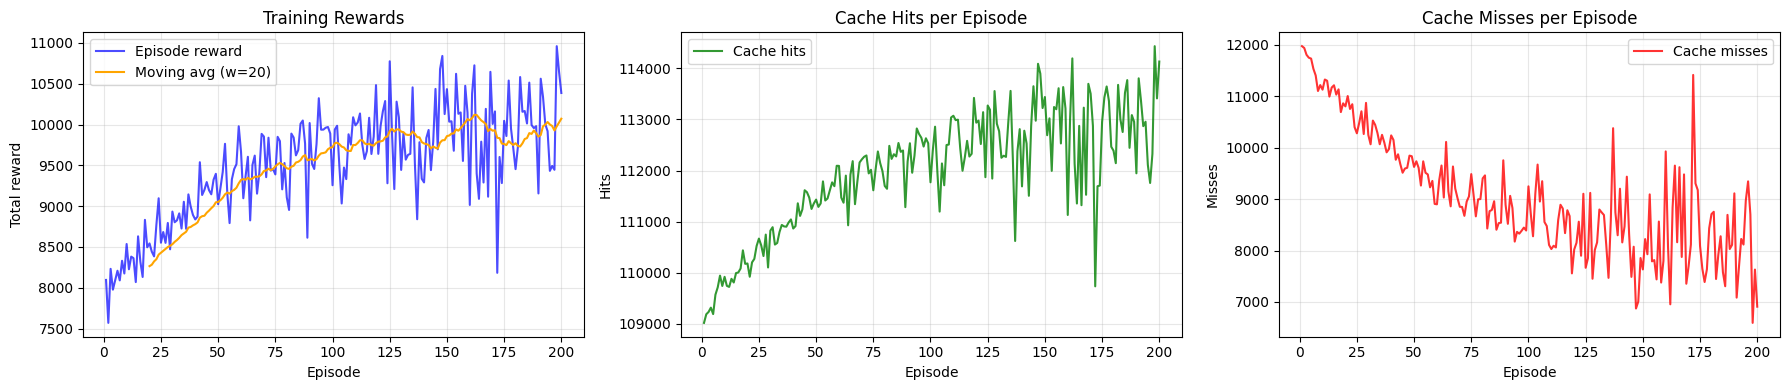

In [ ]:
# Combined plots: rewards (with moving average), cache hits, cache misses
import matplotlib.pyplot as plt

episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()